# LAS REDES SOCIALES A TRAVES DE LAS DISTINTAS GENERACIONES





### Objetivo del Informe EDA
Evaluar el uso de redes sociales a traves de distintas generaciones. Se busca demostrar como la edad es determinante para  la relacion de los usuarios con las plataformas digitales, analizando metricas de productividad, estres, ansiedad y toxicidad.



#### HIPOTESIS 1
Los nativos digitales (Gen Z/Alfa)  A pesar de nacer hiperconectados, el uso intensivo les genera niveles mas altos de ansiedad y disrupciones de sueño que a los adultos.

#### HIPOTESIS 2

Los Millennials y Boomers experimentan una dependencia distinta. Dicen usarlos menos y no tener las consecuencias que tienen los jovenes.


#### HIPOTESIS 3


La forma en que se manifiesta la toxicidad digital depende de la generacion y la plataforma.

# 1. IMPORTACIÓN Y LIMPIEZA

"Iniciamos el proceso cargando el dataset y realizando una limpieza de valores nulos. Tras verificar la integridad de los datos, mantenemos 17,074 registros limpios, los cuales son suficientes para garantizar la representatividad estadística del estudio."

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Carga de datos
direccion = 'datos/Social Media vs Productivity/social_media_vs_productivity.csv'
smp = pd.read_csv(direccion)



# Limpieza de nulos
smp_limpio = smp.dropna().copy()

# ASIGNACIÓN DE GENERACIONES POR EDAD

In [17]:
def asignar_generacion(edad):
    if edad <= 26: return 'Gen Z/Alfa'
    elif 27 <= edad <= 42: return 'Millennial'
    elif 43 <= edad <= 58: return 'Gen X'
    else: return 'Boomer'

# Aplicar la función
smp_limpio['generacion'] = smp_limpio['edad'].apply(asignar_generacion)
print("Generaciones asignadas correctamente.")

Generaciones asignadas correctamente.



# # CONTEXTO GENERAL: DISTRIBUCIÓN DE LA MUESTRA

generacion
Millennial    5844
Gen X         5569
Gen Z/Alfa    3150
Boomer        2511
Name: count, dtype: int64


C:\Users\bootr\AppData\Local\Temp\ipykernel_1744\2181332327.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=smp_limpio, x='generacion', order=orden_generaciones, palette='viridis')


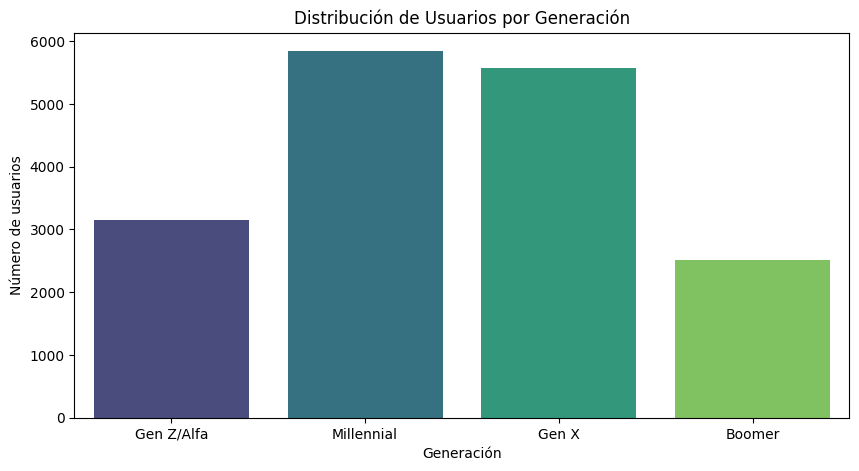

In [18]:
print(smp_limpio['generacion'].value_counts())

plt.figure(figsize=(10, 5))
orden_generaciones = ['Gen Z/Alfa', 'Millennial', 'Gen X', 'Boomer']
sns.countplot(data=smp_limpio, x='generacion', order=orden_generaciones, palette='viridis')
plt.title('Distribución de Usuarios por Generación')
plt.ylabel('Número de usuarios')
plt.xlabel('Generación')
plt.show()

# # ANÁLISIS DE HIPÓTESIS: TRANSVERSALIDAD DEL ESTRÉS

C:\Users\bootr\AppData\Local\Temp\ipykernel_1744\1677149505.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smp_limpio, x='generacion', y='nivel_estres', order=orden_generaciones, palette='viridis', errorbar='ci')


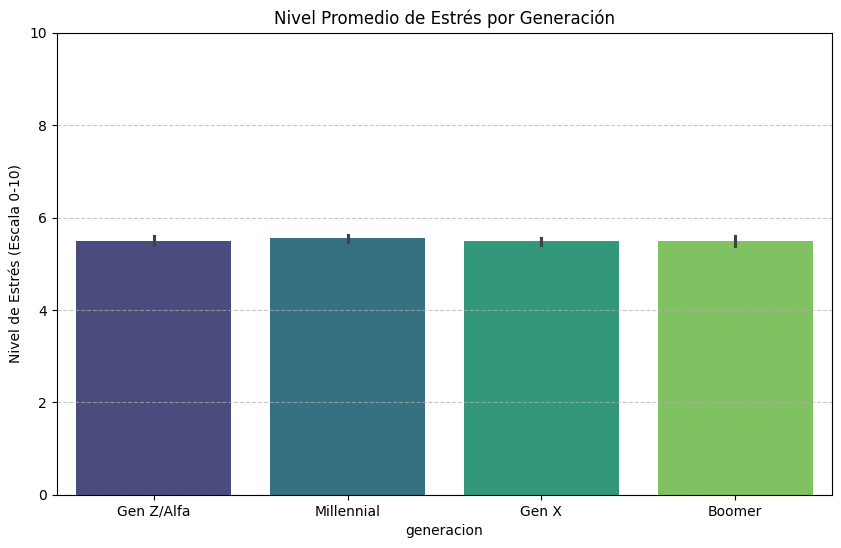

--- ANÁLISIS DE TRANSVERSALIDAD DEL ESTRÉS ---
Generación Gen Z/Alfa: Estrés promedio de 5.49 (±2.88)
Generación Millennial: Estrés promedio de 5.55 (±2.86)
Generación Gen X: Estrés promedio de 5.49 (±2.85)
Generación Boomer: Estrés promedio de 5.50 (±2.89)

Conclusión: La diferencia máxima es de 0.07 puntos. El estrés es transversal.


In [19]:
# Calcular medias
columnas_interes =['nivel_estres', 'horas_sueno', 'tiempo_diario_redes_sociales', 'dias_burnout_mes']
resumen_stats = smp_limpio.groupby('generacion')[columnas_interes].mean()
orden_generaciones = ['Gen Z/Alfa', 'Millennial', 'Gen X', 'Boomer']

# Gráfico de barras de estrés
plt.figure(figsize=(10, 6))
sns.barplot(data=smp_limpio, x='generacion', y='nivel_estres', order=orden_generaciones, palette='viridis', errorbar='ci')
plt.title('Nivel Promedio de Estrés por Generación')
plt.ylabel('Nivel de Estrés (Escala 0-10)')
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Resumen en texto
print("--- ANÁLISIS DE TRANSVERSALIDAD DEL ESTRÉS ---")
resumen = smp_limpio.groupby('generacion')['nivel_estres'].mean()
std_dev = smp_limpio.groupby('generacion')['nivel_estres'].std()
for gen in orden_generaciones:
    print(f"Generación {gen}: Estrés promedio de {resumen[gen]:.2f} (±{std_dev[gen]:.2f})")
print(f"\nConclusión: La diferencia máxima es de {resumen.max() - resumen.min():.2f} puntos. El estrés es transversal.")

# # HALLAZGO FINAL: EL BIENESTAR DIGITAL COMO FACTOR PROTECTOR

Estrés según Bienestar Digital activado:
 bienestar_digital_activado
False    5.542886
True     5.419470
Name: nivel_estres, dtype: float64


C:\Users\bootr\AppData\Local\Temp\ipykernel_1744\2072858955.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smp_limpio, x='bienestar_digital_activado', y='nivel_estres', palette='magma', errorbar='ci')


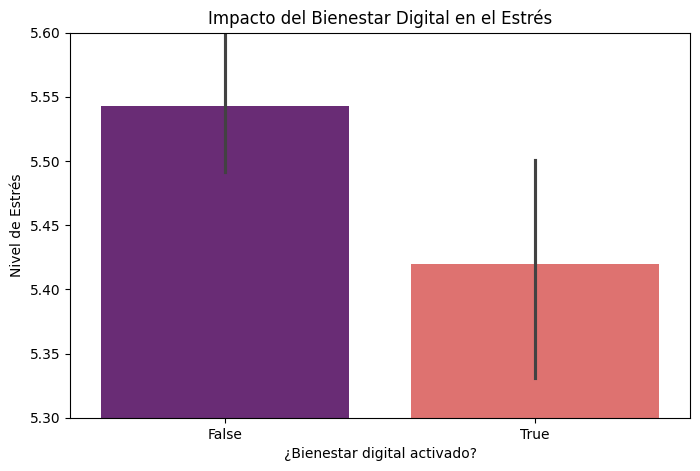

In [20]:
# Análisis de impacto del bienestar digital
impacto = smp_limpio.groupby('bienestar_digital_activado')['nivel_estres'].mean()
print("Estrés según Bienestar Digital activado:\n", impacto)

plt.figure(figsize=(8, 5))
sns.barplot(data=smp_limpio, x='bienestar_digital_activado', y='nivel_estres', palette='magma', errorbar='ci')
plt.title('Impacto del Bienestar Digital en el Estrés')
plt.xlabel('¿Bienestar digital activado?')
plt.ylabel('Nivel de Estrés')
plt.ylim(5.3, 5.6)
plt.show()

# CONCLUSIONES DEL INFORME
- **Sobre las Generaciones:** Se ha demostrado que el nivel de estrés no es una variable dependiente de la edad. La transversalidad del estrés digital sugiere que estamos ante un problema de diseño tecnológico y hábitos de uso, no de brecha generacional.
- **Sobre las Soluciones:** La variable `bienestar_digital_activado` presenta una correlación positiva con la reducción del estrés. Recomendamos priorizar la educación en el uso de estas herramientas por encima de enfoques segmentados por edad.